In [1]:
import os
os.environ["SCIPY_ARRAY_API"] = "1"
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import importlib
import sys
import torch

In [2]:
from sklearn.decomposition import PCA

In [3]:
from scipy.stats import spearmanr,pearsonr

In [4]:
import SCAPE

/home/yuntianf/softwares/anaconda3/envs/causal/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-05 18:25:07.516396: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [12]:
importlib.reload(SCAPE)

<module 'SCAPE' from '/mnt/c/yuntian/Necessary/Upenn/Thesis/project/spatial_causal/analysis/SCAPE/SCAPE/__init__.py'>

In [31]:
mm_to_in = 1 / 25.4

### function

In [5]:
def center_scale(X,eps = 1e-8):
    X = np.asarray(X, float).copy()
    mu = X.mean(axis=0, keepdims=True)
    sd = X.std(axis=0, keepdims=True)
    
    X = (X - mu)/sd
    
    return(X)

### data simulation

In [116]:
tau = 1
data = SCAPE.simulate_observed_confounder(
    n_slides_pre=3, n_slides_post=3, 
    d_u=25, d_c=5, tau = tau,
    U_simulator = SCAPE.continuity_generator,
    # U_simulator = SCAPE.cluster_generator,
    # U_simulator_kwargs = {"n_clusters":3},
    w_t_mu = 0,w_t_sd = 1, t_intercept = -0.1,
    alpha_y =4,alpha_t = 4,

    add_batch = False,
    batch_additive_sd=1, batch_rank=3, batch_scale_sd=0.2,
    batch_rot_sd = 0.03, batch_mix_rank= 2, batch_mix_sd = 0.08,
    seed=512
)

In [117]:
out_path = "../../../data/simulation/continuity_at4_ay4_nobatch/"

In [118]:
os.makedirs(out_path, exist_ok=True)

### Sanity check

#### true confounder matrix

In [119]:
labels = data["slide_id"]
is_post = data["is_post"] == 1
is_treated = data["T"] == 1

U = center_scale(data["X"])

pca = PCA() 
U_pca = pca.fit(U) 
U_pca_coord = pca.transform(U)

In [120]:
post_id = np.where(is_post, "case", "control")

##### visualization

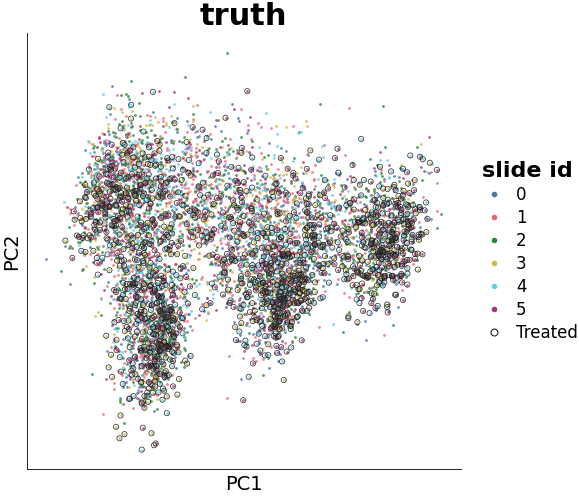

In [121]:
fig, ax = SCAPE.scatter(U_pca_coord, data["slide_id"],data["T"],group_title = "slide id",
                        width = 140,height = 120,show_ticks=False,title = "truth",
                       xlab_label = "PC1",ylab_label = "PC2")

In [122]:
fig.savefig(out_path+"scatter_slide_truth.pdf")

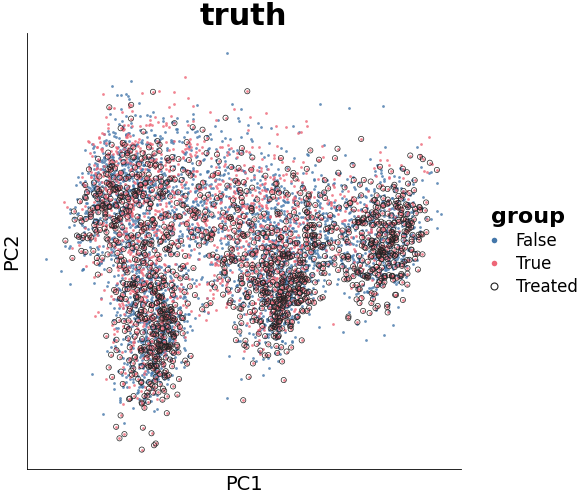

In [123]:
fig, ax = SCAPE.scatter(U_pca_coord, data["is_post"],data["T"],group_title = "group",
                        width = 140,height = 120,show_ticks=False,title = "truth",
                        xlab_label = "PC1",ylab_label = "PC2")

In [124]:
fig.savefig(out_path+"scatter_post_truth.pdf")

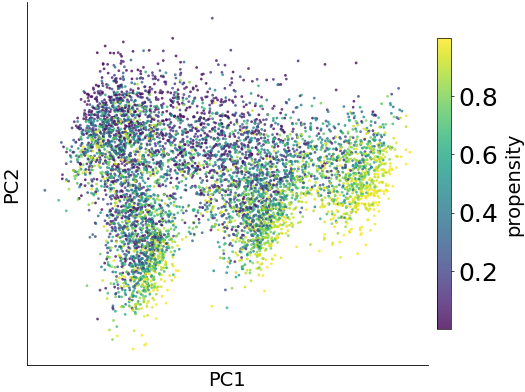

In [125]:
fig, ax = SCAPE.scatter(U_pca_coord, data["p"],group_title = "propensity",
                        width = 140,height = 120,show_ticks=False,
                        xlab_label = "PC1",ylab_label = "PC2")

In [126]:
fig.savefig(out_path+"scatter_p_truth.pdf")

##### causal estimation (regression)

In [107]:
causal_truth = SCAPE.aipw_ate_crossfit(U_pca_coord,data["T"],data["Y"].reshape(-1, 1))

Text(0, 0.5, 'e (estimation)')

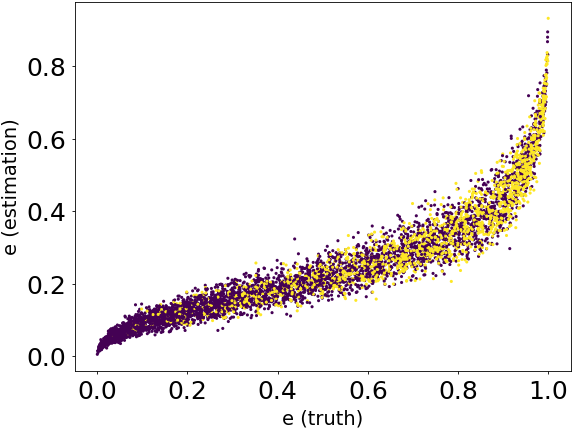

In [108]:
plt.scatter(data["p"],
            causal_truth["e_hat"],
            s = 5,
            c = data["T"],
            edgecolors='none',   # border color
            linewidths=0.5,
            alpha = 1)
plt.xlabel("e (truth)")
plt.ylabel("e (estimation)")

Text(0, 0.5, 'Y (estimation)-Y (truth)')

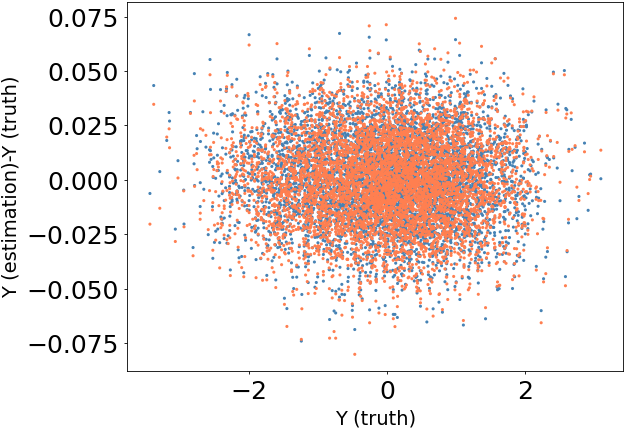

In [109]:
plt.scatter(data["Y"],
            causal_truth["m0_hat"]-data["Y"],
            s = 5,
            c = "steelblue",
            edgecolors='none',   # border color
            linewidths=0.5,
            alpha = 1)
plt.scatter(data["Y"],
            causal_truth["m1_hat"]-data["Y"],
            s = 5,
            c = "coral",
            edgecolors='none',   # border color
            linewidths=0.5,
            alpha = 1)
plt.xlabel("Y (truth)")
plt.ylabel("Y (estimation)-Y (truth)")

In [110]:
causal_truth["ate"]

np.float64(-0.0011425867796032894)

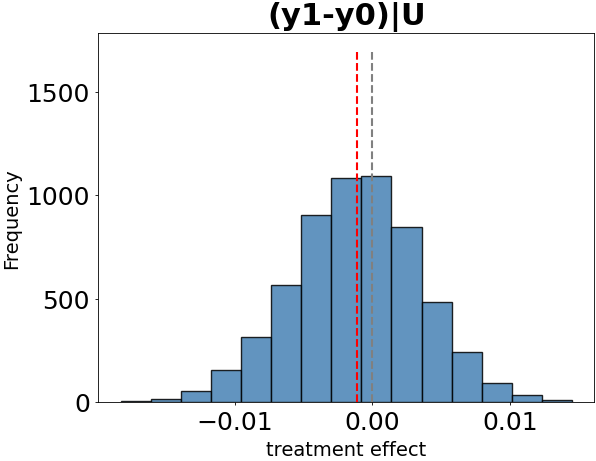

In [111]:
title = "(y1-y0)|U"
plt.hist(causal_truth["m1_hat"]-causal_truth["m0_hat"], 
         bins=15,color='steelblue', edgecolor='black', alpha=0.85)
plt.vlines(x=tau, ymin=0, ymax=1700, color='grey', linestyle='--')
plt.vlines(x=causal_truth["ate"], ymin=0, ymax=1700, color='red', linestyle='--')
plt.xlabel("treatment effect")
plt.ylabel("Frequency")
plt.title(title)
plt.show()

#### observational confounder matrix

In [127]:
labels = data["slide_id"]
treated = data["T"]

K = center_scale(data["K"])

pca = PCA() 
# K_pca = pca.fit(K[treated == 0]) 
K_pca = pca.fit(U) 
K_pca_coord = pca.transform(K)

##### visualization

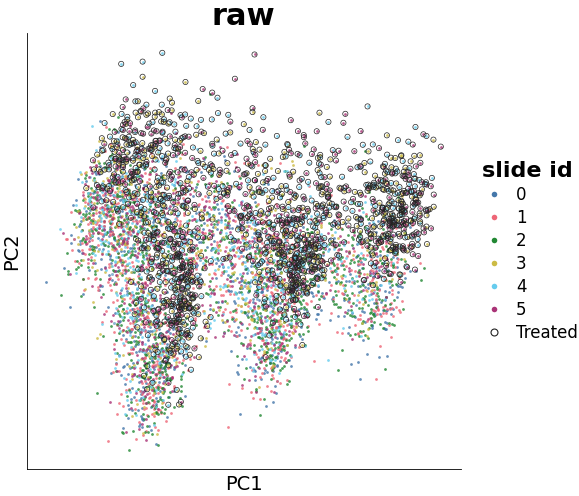

In [128]:
fig, ax = SCAPE.scatter(K_pca_coord, data["slide_id"],data["T"],group_title = "slide id",
                        width = 140,height = 120,show_ticks=False,title = "raw",
                        xlab_label = "PC1",ylab_label = "PC2")

In [129]:
fig.savefig(out_path+"scatter_slide_raw.pdf")

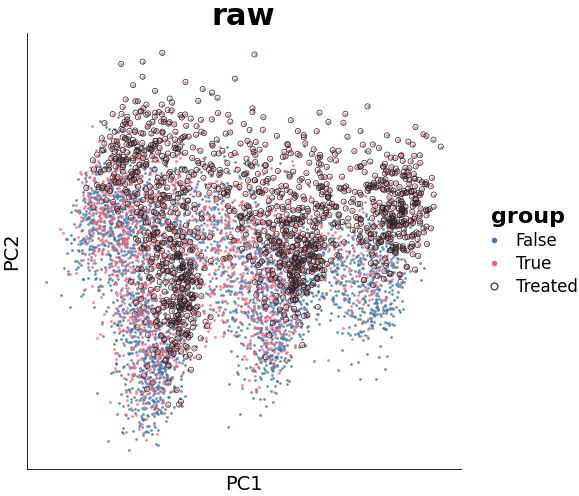

In [130]:
fig, ax = SCAPE.scatter(K_pca_coord, data["is_post"],data["T"],group_title = "group",
                        width = 140,height = 120,show_ticks=False,title = "raw",
                        xlab_label = "PC1",ylab_label = "PC2")

In [131]:
fig.savefig(out_path+"scatter_post_raw.pdf")

##### causal estimation (regression)

In [132]:
K_pca = pca.fit(K[data["T"] == 0])
K_pca_coord = K_pca.transform(K)

In [133]:
causal_raw = SCAPE.aipw_ate_crossfit(K_pca_coord,data["T"],data["Y"].reshape(-1, 1))

In [134]:
spearmanr(data["p"],causal_raw["e_hat"])[0]

np.float64(0.2898377275807561)

Text(0, 0.5, 'e (estimation)')

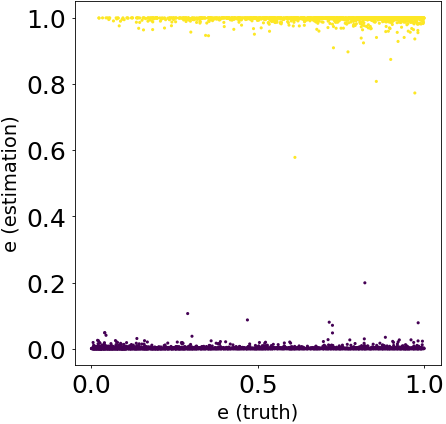

In [135]:
fig, ax = plt.subplots(figsize=(120 * mm_to_in, 120 * mm_to_in))
ax.scatter(data["p"],
            causal_raw["e_hat"],
            c = data["T"],
            s = 5,
            edgecolors='none',   # border color
            linewidths=0.5,
            alpha = 1)
ax.set_xlabel("e (truth)")
ax.set_ylabel("e (estimation)")

In [136]:
fig.savefig(out_path+"raw_propensity_comp.pdf")

Text(0, 0.5, 'Y (estimation)-Y (truth)')

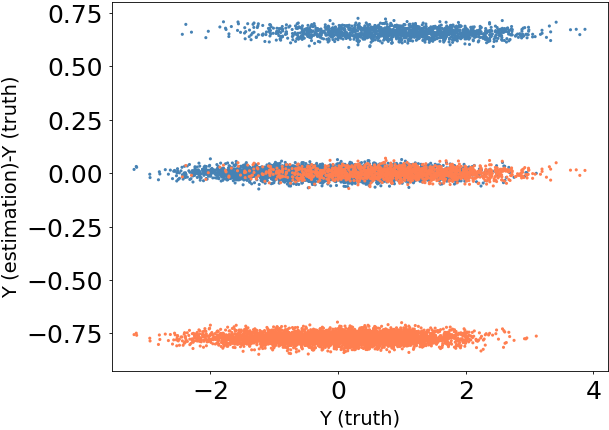

In [137]:
plt.scatter(data["Y"],
            causal_raw["m0_hat"]-data["Y"],
            s = 5,
            c = "steelblue",
            edgecolors='none',   # border color
            linewidths=0.5,
            alpha = 1)
plt.scatter(data["Y"],
            causal_raw["m1_hat"]-data["Y"],
            s = 5,
            c = "coral",
            edgecolors='none',   # border color
            linewidths=0.5,
            alpha = 1)
plt.xlabel("Y (truth)")
plt.ylabel("Y (estimation)-Y (truth)")

In [138]:
causal_raw["ate"]

np.float64(-0.7217687480962952)

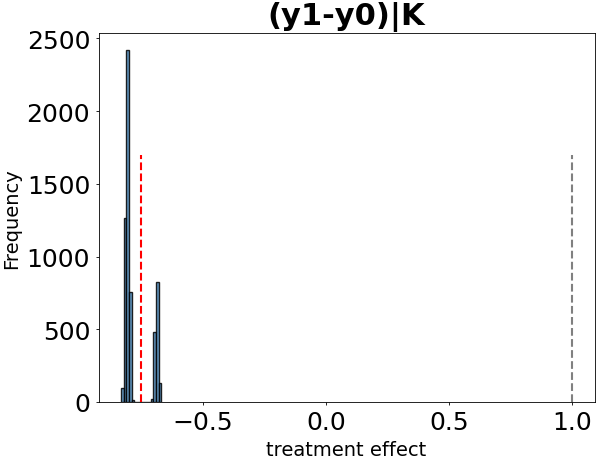

In [37]:
title = "(y1-y0)|K"
plt.hist(causal_raw["m1_hat"]-causal_raw["m0_hat"], 
         bins=15,color='steelblue', edgecolor='black', alpha=0.85)
plt.vlines(x=1, ymin=0, ymax=1700, color='grey', linestyle='--')
plt.vlines(x=causal_raw["ate"], ymin=0, ymax=1700, color='red', linestyle='--')
plt.xlabel("treatment effect")
plt.ylabel("Frequency")
plt.title(title)
plt.show()

### Batch removal

#### harmony

In [101]:
Z = SCAPE.harmony(K_pca_coord[data["T"] == 0],data["slide_id"][data["T"] == 0])

2026-04-02 13:11:13,084 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-04-02 13:11:13,194 - harmonypy - INFO - KMeans initialization complete.


#### symphony

In [97]:
model = SCAPE.Symphony(
    n_pcs=30,
    n_clusters=100,      # or None for Symphony-like default min(100, n_ref // 30)
    sigma=0.1,          # Symphony default
    harmony_theta=2.0,  # Harmony/Symphony default
    harmony_lambda=1.0,
    harmony_max_iter=50,
    random_state=0,
)

out = model.fit_transform(K,data["slide_id"],treated = data["T"])

2026-04-02 13:03:06,848 - harmonypy - INFO - Running Harmony (PyTorch on cuda)
2026-04-02 13:03:06,852 - harmonypy - INFO -   Parameters:
2026-04-02 13:03:06,856 - harmonypy - INFO -     max_iter_harmony: 50
2026-04-02 13:03:06,857 - harmonypy - INFO -     max_iter_kmeans: 20
2026-04-02 13:03:06,860 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-04-02 13:03:06,861 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-04-02 13:03:06,861 - harmonypy - INFO -     nclust: 100
2026-04-02 13:03:06,868 - harmonypy - INFO -     block_size: 0.05
2026-04-02 13:03:06,869 - harmonypy - INFO -     lamb: [1. 1. 1. 1. 1. 1.]
2026-04-02 13:03:06,870 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2.]
2026-04-02 13:03:06,875 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-04-02 13:03:06,878 - harmonypy - INFO -     verbose: True
2026-04-02 13:03:06,878 - harmonypy - INFO -     random_state: 0
2026-04-02 13:03:06,879 - harmonypy - INFO -   Data: 30 PCs × 4560 cells
2026-04-02 13:03:0

In [98]:
Z = out["Z_all_harmony"]  

#### visualization

(<Figure size 720.472x520 with 1 Axes>, <Axes: xlabel='Dim 1', ylabel='Dim 2'>)

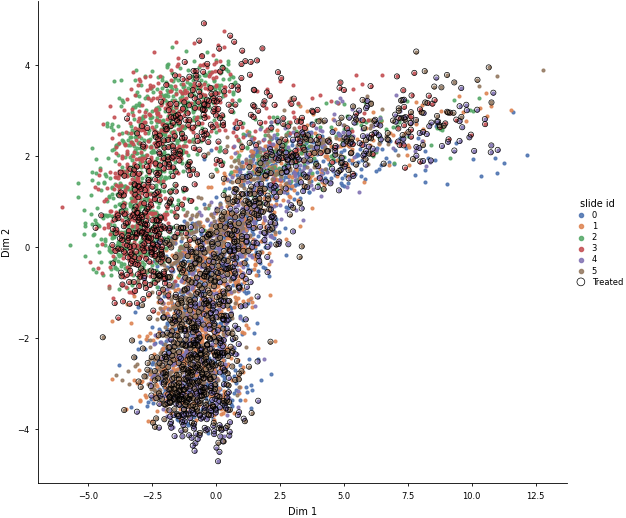

In [99]:
SCAPE.scatter(Z, data["slide_id"],data["T"],group_title = "slide id")

(<Figure size 720.472x520 with 1 Axes>, <Axes: xlabel='Dim 1', ylabel='Dim 2'>)

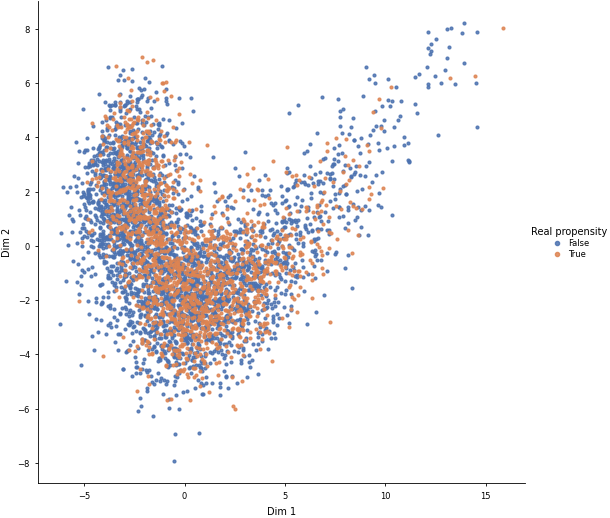

In [95]:
SCAPE.scatter(U_pca_coord[data["T"] == 0], data["is_post"][data["T"] == 0],group_title = "Real propensity")

(<Figure size 720.472x520 with 2 Axes>, <Axes: xlabel='Dim 1', ylabel='Dim 2'>)

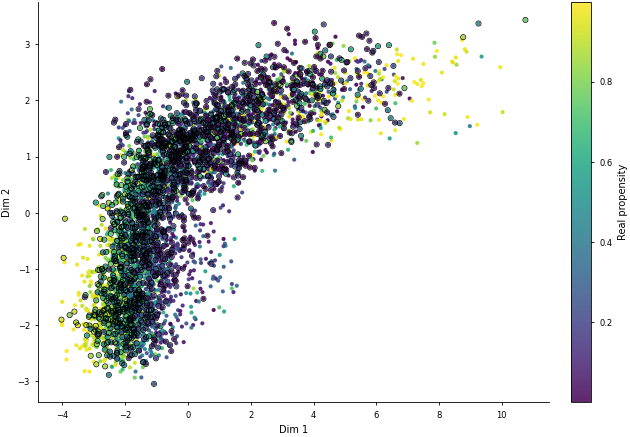

In [104]:
SCAPE.scatter(Z,data["p"][data["T"] == 0], data["is_post"][data["T"] == 0],group_title = "Real propensity")

#### causal estimation (regression)

In [28]:
causal_debatch = SCAPE.aipw_ate_crossfit(Z,data["T"],data["Y"].reshape(-1, 1))

Text(0, 0.5, 'e (estimation)')

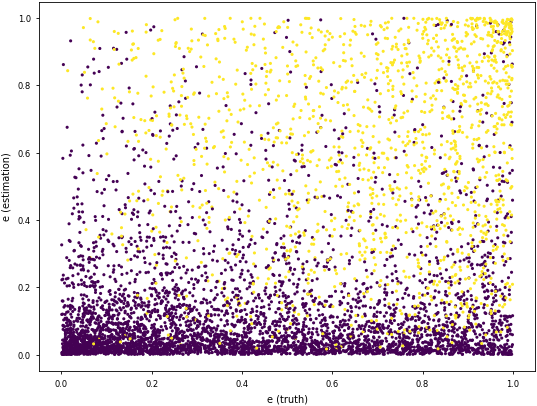

In [29]:
plt.scatter(data["p"],
            causal_debatch["e_hat"],
            s = 5,
            c = data["T"],
            edgecolors='none',   # border color
            linewidths=0.5,
            alpha = 1)
plt.xlabel("e (truth)")
plt.ylabel("e (estimation)")

In [30]:
causal_debatch["ate"]

np.float64(-0.25022575312638873)

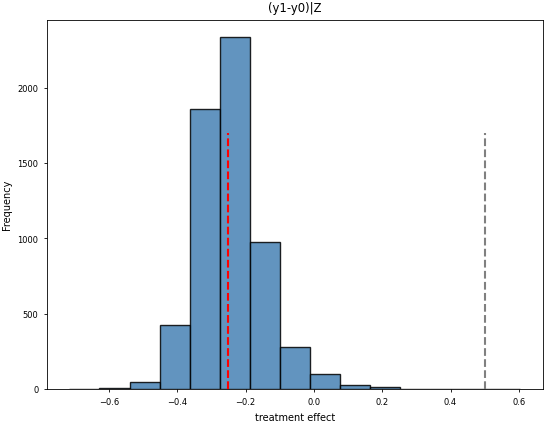

In [31]:
title = "(y1-y0)|Z"
plt.hist(causal_debatch["m1_hat"]-causal_debatch["m0_hat"], 
         bins=15,color='steelblue', edgecolor='black', alpha=0.85)
plt.vlines(x=tau, ymin=0, ymax=1700, color='grey', linestyle='--')
plt.vlines(x=causal_debatch["ate"], ymin=0, ymax=1700, color='red', linestyle='--')
plt.xlabel("treatment effect")
plt.ylabel("Frequency")
plt.title(title)
plt.show()

### Collider Removal

In [139]:
if torch.cuda.is_available():
    JOT_DEVICE = "cuda"
    JOT_DTYPE  = torch.float32
else:
    JOT_DEVICE = "cpu"
    JOT_DTYPE  = torch.float64

In [140]:
importlib.reload(SCAPE)

<module 'SCAPE' from '/mnt/c/yuntian/Necessary/Upenn/Thesis/project/spatial_causal/analysis/SCAPE/SCAPE/__init__.py'>

In [141]:
Z = K_pca_coord

In [142]:
cfg = SCAPE.JointEntropicConfig(
    device=JOT_DEVICE,
    epsilon=0.05,
    beta_treated=0.25,   # if you want to favor untreated
    n_iters=5000,
    lr=0.5,
    verbose_every=100,
    tol_col=1e-6,
    tol_row=1e-6,
    stable_patience=20,
    lr_patience=80,
    lr_decay=0.5,
    min_lr=5e-5,
    stop_patience=300,
)

In [143]:
result = SCAPE.fit_jot(X = Z,is_post = data["is_post"],is_treated = data["T"],cfg = cfg)

[iter 0001] dual=-0.704236 col_u=4.928e-01 col_t=2.864e-01 overcap=0.000e+00 score=7.792e-01 lr=5.000e-01 best_iter=1
[iter 0081] plateau/degrade detected: restore best_iter=1, reduce lr 5.000e-01 -> 2.500e-01, reset optimizer state
[iter 0100] dual=-2.677545 col_u=5.187e-01 col_t=4.816e-01 overcap=5.159e-03 score=1.005e+00 lr=2.500e-01 best_iter=1
[iter 0161] plateau/degrade detected: restore best_iter=1, reduce lr 2.500e-01 -> 1.250e-01, reset optimizer state
[iter 0200] dual=-1.738568 col_u=5.134e-01 col_t=4.818e-01 overcap=2.667e-03 score=9.979e-01 lr=1.250e-01 best_iter=166
[iter 0246] plateau/degrade detected: restore best_iter=166, reduce lr 1.250e-01 -> 6.250e-02, reset optimizer state
[iter 0300] dual=-0.621019 col_u=2.259e-02 col_t=1.381e-02 overcap=1.325e-02 score=4.964e-02 lr=6.250e-02 best_iter=300
[iter 0400] dual=-0.620826 col_u=1.314e-04 col_t=1.015e-04 overcap=2.366e-04 score=4.696e-04 lr=6.250e-02 best_iter=397
[iter 0500] dual=-0.620826 col_u=2.751e-06 col_t=6.289e-0

#### visualization

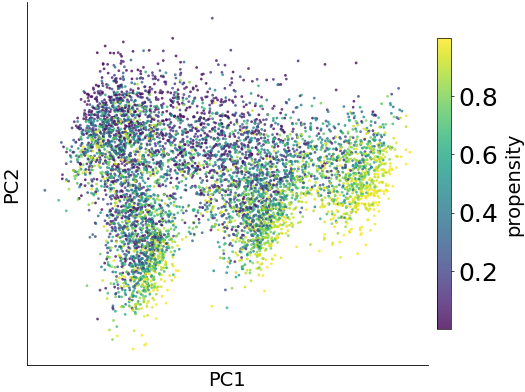

In [144]:
fig, ax = SCAPE.scatter(U_pca_coord, data["p"],group_title = "propensity",
                        width = 140,height = 120,show_ticks=False,
                        xlab_label = "PC1",ylab_label = "PC2")

In [145]:
residual_pre = result["P_t"].sum(axis = 0)

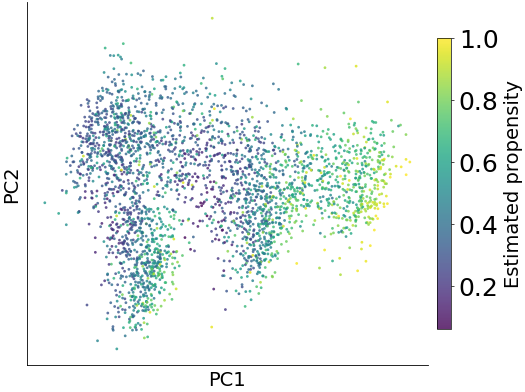

In [146]:
fig, ax = SCAPE.scatter(U_pca_coord[data["is_post"] == 0], residual_pre/residual_pre.max(),
                        group_title = "Estimated propensity",
                        width = 140,height = 120,show_ticks=False,
                        xlab_label = "PC1",ylab_label = "PC2")

Text(0, 0.5, 'e (estimation)')

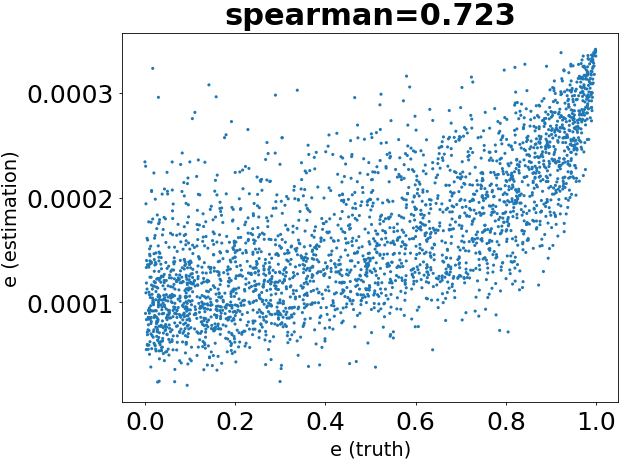

In [147]:
cor = spearmanr(data["p"][data["is_post"] == 0],residual_pre)[0]
plt.scatter(data["p"][data["is_post"] == 0],
            residual_pre,
            s = 5,
            edgecolors='none',   # border color
            linewidths=0.5,
            alpha = 1)
plt.title(f"spearman={round(cor,3)}")
plt.xlabel("e (truth)")
plt.ylabel("e (estimation)")

#### projection

In [148]:
post_pre_map = SCAPE.row_mass_sparsify(result["P_full"], keep_mass=0.9)

In [149]:
map_sample = SCAPE.sample_map_projection(post_pre_map,U_pca_coord[data["is_post"] == 0],n_samples = 60)

In [150]:
X = U_pca_coord.copy()
X[data["is_post"]] = map_sample[1]

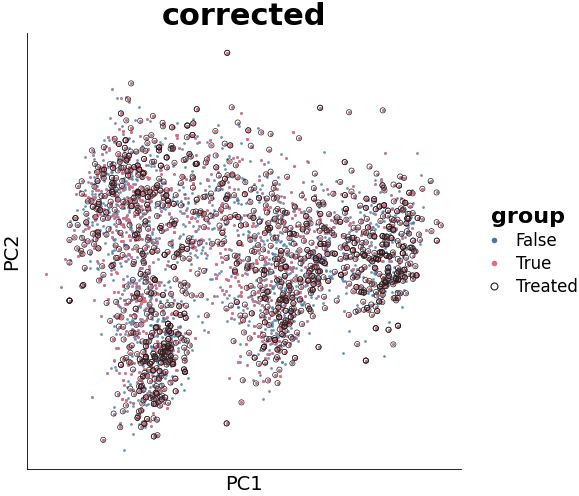

In [151]:
fig, ax = SCAPE.scatter(X, data["is_post"],data["T"],group_title = "group",
                        width = 140,height = 120,show_ticks=False,title = "corrected",
                        xlab_label = "PC1",ylab_label = "PC2")

In [152]:
fig.savefig(out_path+"scatter_post_corrected.pdf")

#### causal inference

##### smooth expression

In [153]:
G1_map = SCAPE.row_mass_sparsify(result["P_u"].T, keep_mass=0.9)
G2_map = SCAPE.row_mass_sparsify(result["P_t"].T, keep_mass=0.9)

In [154]:
ITE = G2_map @ (data["Y"][is_post & is_treated][:,None]) - G1_map @ (data["Y"][is_post & ~is_treated][:,None])

In [155]:
ITE.mean()

np.float64(0.6268379177609521)

##### ridge regression

In [156]:
ATE = []
propensity = []
m0_hat = []
m1_hat = []

for i in map_sample:
    X_corrected = i
    causal = SCAPE.aipw_ate_crossfit(X_corrected,data["T"][is_post],data["Y"][is_post].reshape(-1, 1))
    ATE.append(causal["ate"])
    propensity.append(causal["e_hat"])
    
    
    m0_hat.append(causal["m0_hat"])
    m1_hat.append(causal["m1_hat"])

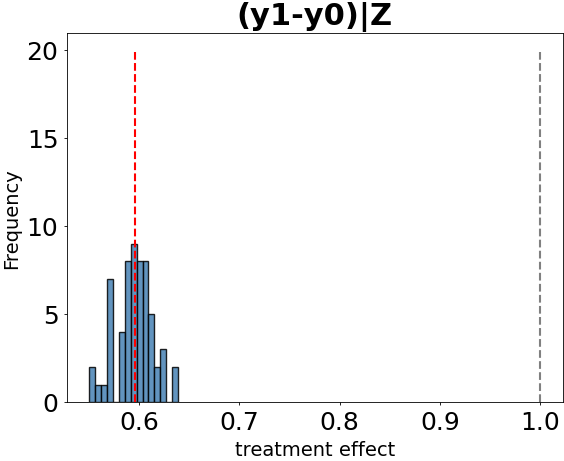

In [157]:
title = "(y1-y0)|Z"
plt.hist(ATE, 
         bins=15,color='steelblue', edgecolor='black', alpha=0.85)
plt.vlines(x=tau, ymin=0, ymax=20, color='grey', linestyle='--')
plt.vlines(x=np.mean(ATE), ymin=0, ymax=20, color='red', linestyle='--')
plt.xlabel("treatment effect")
plt.ylabel("Frequency")
plt.title(title)
plt.show()

In [158]:
np.mean(ATE)

np.float64(0.5955434497910346)

In [159]:
m0_hat_mean = np.mean(np.stack(m0_hat), axis=0)
m1_hat_mean = np.mean(np.stack(m1_hat), axis=0)
propensity = np.vstack(propensity)

Text(0, 0.5, 'Y (estimation)-Y (truth)')

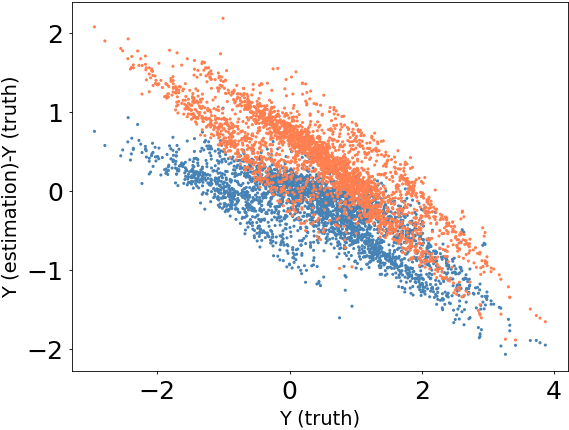

In [160]:
plt.scatter(data["Y"][is_post],
            m0_hat_mean-data["Y"][is_post],
            s = 5,
            c = "steelblue",
            edgecolors='none',   # border color
            linewidths=0.5,
            alpha = 1)
plt.scatter(data["Y"][is_post],
            m1_hat_mean-data["Y"][is_post],
            s = 5,
            c = "coral",
            edgecolors='none',   # border color
            linewidths=0.5,
            alpha = 1)
plt.xlabel("Y (truth)")
plt.ylabel("Y (estimation)-Y (truth)")

In [161]:
post_idx = np.where(is_post)
t_post = is_treated[post_idx]

idx_u_local = np.where(t_post == 0)[0]
idx_t_local = np.where(t_post == 1)[0]

In [162]:
spearmanr(data["p"][is_post],np.mean(propensity,axis = 0))[0]

np.float64(0.7628724474506999)

Text(0, 0.5, 'e (estimation)')

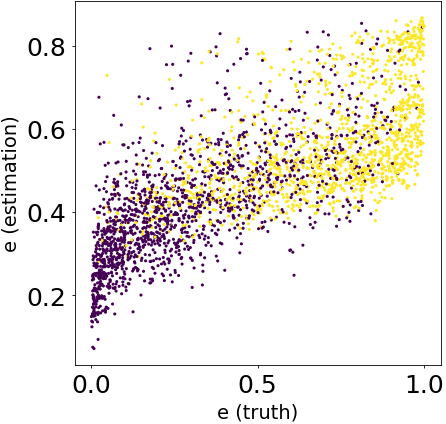

In [163]:
u_cor = spearmanr(data["p"][is_post & ~is_treated],np.mean(propensity,axis = 0)[idx_u_local])[0]
t_cor = spearmanr(data["p"][is_post & is_treated],np.mean(propensity,axis = 0)[idx_t_local])[0]
fig, ax = plt.subplots(figsize=(120 * mm_to_in, 120 * mm_to_in))
ax.scatter(data["p"][is_post],
            np.mean(propensity,axis = 0),
            s = 5,
            c = data["T"][is_post],
            edgecolors='none',   # border color
            linewidths=0.5,
            alpha = 1)
# plt.title(f"u_cor={round(u_cor,2)},t_cor={round(t_cor,2)}")
ax.set_xlabel("e (truth)")
ax.set_ylabel("e (estimation)")

In [164]:
fig.savefig(out_path+"jot_propensity_comp.pdf")

In [165]:
aipw_ave = SCAPE.aipw_ite_ow(data["Y"][is_post].reshape(-1, 1), 
               data["T"][is_post], 
               m0_hat_mean, m1_hat_mean, 
               np.mean(propensity,axis = 0))

In [166]:
np.mean(aipw_ave)

np.float64(0.5564462243509656)